In [19]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [20]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

In [21]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [22]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [23]:
df.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-02,2024,7,2024-07-01,41.27085,24.027688,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,2024-07-02,41.27085,24.027688,14768.0,14681.0,2024-06-02,41.250189,24.05011,2024-07-01,2024-06-02,0.0
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-03,2024,7,2024-07-01,41.27085,24.027688,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,2024-07-03,41.27085,24.027688,14967.0,14425.0,2024-06-02,41.250189,24.05011,2024-07-02,2024-06-02,0.0
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-04,2024,7,2024-07-01,41.27085,24.027688,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,2024-07-04,41.27085,24.027688,14967.0,14425.0,2024-06-02,41.250189,24.05011,2024-07-03,2024-06-02,0.0
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-05,2024,7,2024-07-01,41.27085,24.027688,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,2024-07-05,41.27085,24.027688,14967.0,14365.0,2024-06-02,41.250189,24.05011,2024-07-04,2024-06-02,0.0
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-06,2024,7,2024-07-06,41.27085,24.027688,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,2024-07-06,41.27085,24.027688,14967.0,14602.0,2024-06-02,41.250189,24.05011,2024-07-05,2024-06-02,0.0


In [24]:
df['dt_placement'] = pd.to_datetime(df['dt_placement'])
df['indices_image_date'] = pd.to_datetime(df['indices_image_date'])
df['lst_image_date'] = pd.to_datetime(df['lst_image_date'])
df['indices_image_date.1'] = pd.to_datetime(df['indices_image_date.1'])
df['dt_placement_minus_1'] = pd.to_datetime(df['dt_placement_minus_1'])
df['dt_placement_minus_1_avail'] = pd.to_datetime(df['dt_placement_minus_1_avail'])

Text(0.5, 1.0, 'Year: 2024')

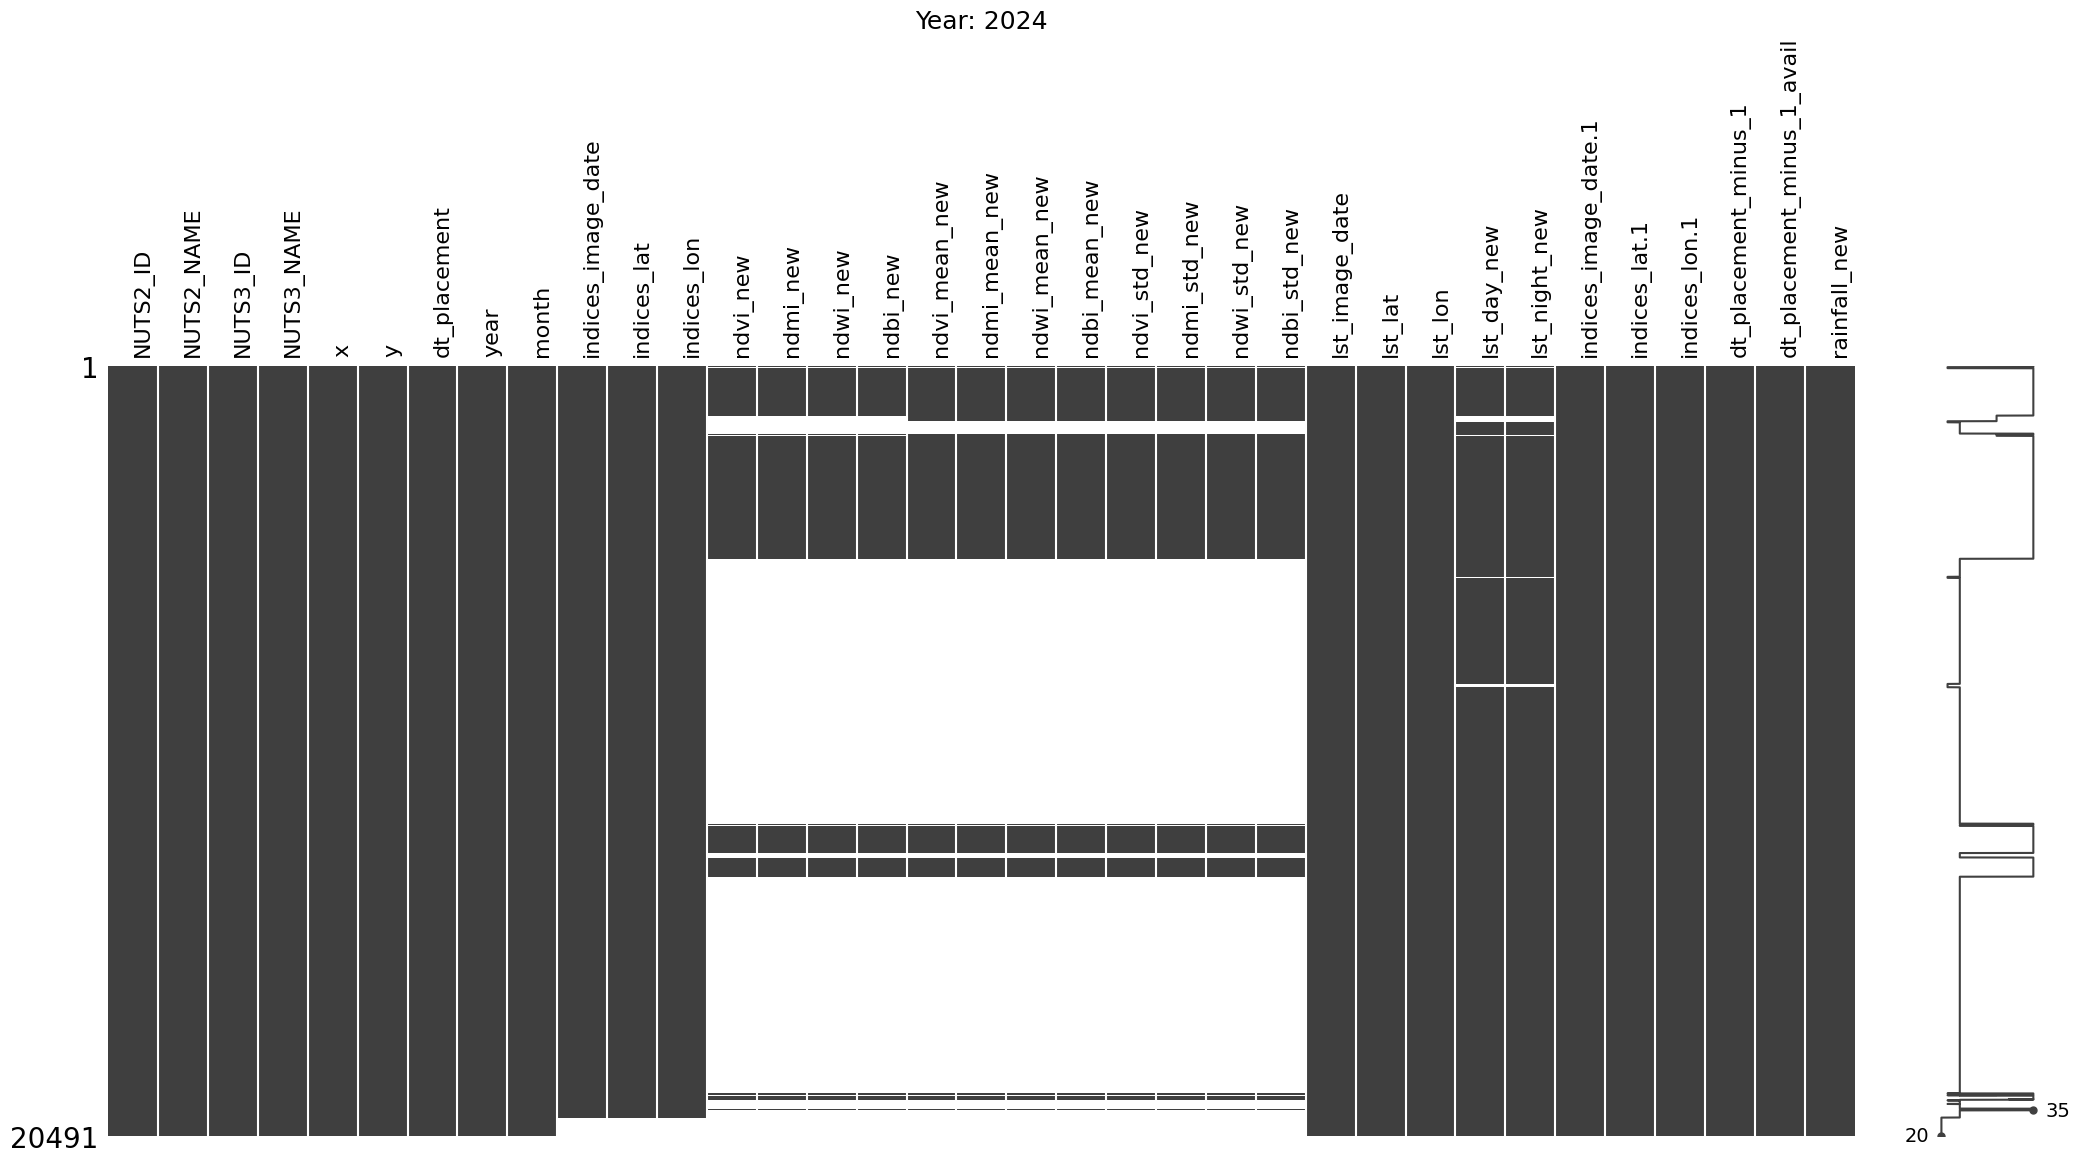

In [25]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df.year.iloc[0]}", fontsize=18)

In [26]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
9,indices_image_date,2.3962
10,indices_lat,2.3962
11,indices_lon,2.3962
12,ndvi_new,70.5041
13,ndmi_new,70.5041
14,ndwi_new,70.5041
15,ndbi_new,70.5041
16,ndvi_mean_new,69.5915
17,ndmi_mean_new,69.5915
18,ndwi_mean_new,69.5915


In [27]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [28]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
9,indices_image_date,2.3962
10,ndvi,70.5041
11,ndmi,70.5041
12,ndwi,70.5041
13,ndbi,70.5041
14,ndvi_mean,69.5915
15,ndmi_mean,69.5915
16,ndwi_mean,69.5915
17,ndbi_mean,69.5915
18,ndvi_std,69.5915


In [29]:
df2 = df.copy()

In [30]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [31]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
9,indices_image_date,2.3962
10,ndvi,74.3058
11,ndmi,74.3058
12,ndwi,74.3058
13,ndbi,74.3058
14,ndvi_mean,73.5152
15,ndmi_mean,73.5152
16,ndwi_mean,73.5152
17,ndbi_mean,73.5152
18,ndvi_std,73.5152


In [32]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [33]:
df2.reset_index(drop=True, inplace=True)

In [34]:
df2

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-02,2024,7,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,14768.0,14681.0,NaN
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-03,2024,7,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,14967.0,14425.0,NaN
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-04,2024,7,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,14967.0,14425.0,NaN
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-05,2024,7,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,14967.0,14365.0,NaN
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306,2024-07-06,2024,7,0.426383,0.018342,-0.403841,-0.018342,0.446694,0.014529,-0.428727,-0.014529,0.070855,0.060511,0.041797,0.060511,14967.0,14602.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20486,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,40.91163,2024-08-01,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15630.0,14755.0,NaN
20487,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.23503,2024-08-01,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15203.0,14689.0,NaN
20488,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.19910,2024-08-01,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15395.0,14735.0,NaN
20489,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,41.19910,2024-08-01,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15424.0,14750.0,NaN


Text(0.5, 1.0, 'Year: 2024')

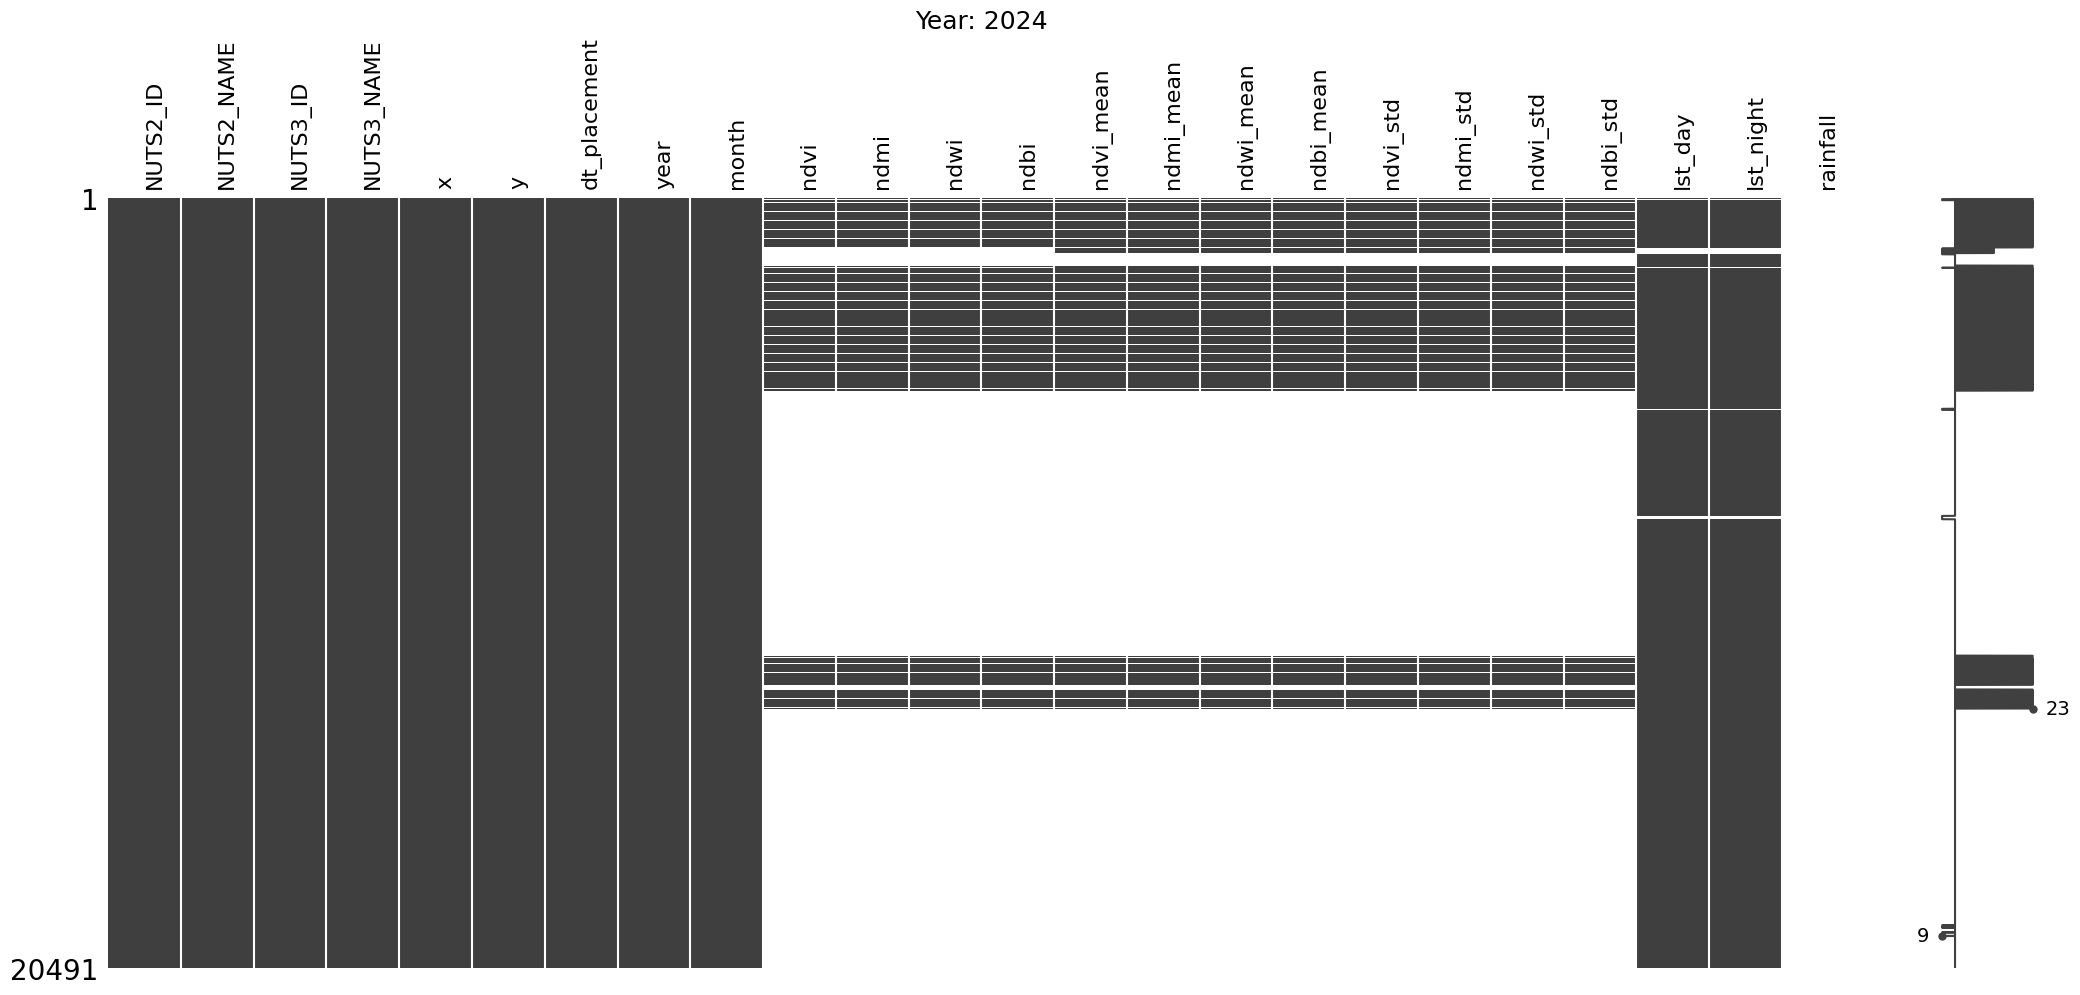

In [35]:
msno.matrix(df2, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df2.year.iloc[0]}", fontsize=18)

In [36]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding='utf-8')